# Speed dating prediction
## Part 2 - Clustering

In [ ]:
from sklearn.datasets import fetch_openml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score

## Team identification



*   seminar SB M15 Monday 16:15 - 17:45
*   Team Speed Dating
*   Team members: Anna Ryglová, Martin Samaš, Martin Snížek, Jitka Šálková, Viktorie Švorcová


# Introduction

### The business value of predicting romantic compatibility
The business value of predicting romantic copatibility lies in transforming dating platforms from simple search engines, relying only on age range, location and stated preferences, to complex predictive tools that take into account many variables such as interests, field of study etc. The services can significantly increase user retention by offering profiles with higher probability of match by filtering information which is really important to people. We find implementing a machine learning classifier to predict a match highly interesting to explore.

###Link to the source of the data:
 https://www.openml.org/search?type=data&status=active&qualities.NumberOfClasses=%3D_2&id=40536&fbclid=IwY2xjawRA1mJleHRuA2FlbQIxMABicmlkETE1V0QwSk81YXI3WXVKZEpyc3J0YwZhcHBfaWQQMjIyMDM5MTc4ODIwMDg5MgABHhFJRnVMWvV629-NpzsoHvio19-5_IXjx8qqVl2NIyZuEdqeXh_KcOumqy0S_aem_biu4lBid3yPPO34x0wEi6Q&sort=runs

### A brief description of the dataset
**Speed dating dataset (OpenML #40536)**

**authors**: Ray Fisman and Sheena Iyengar, Columbia Business School

8 378 rows

Data was collected from 21 experimental speed dating events at Columbia University during the years 2002-2004.

Each event consists of a four-minute first date of two people of opposite sex. After the date, both participants recorded whether they wanted to see the other participant again. (both yes = 1 = match) The participants complete questionnaires before (preferences, demographics and lifestyle), during (rating of a partner) and after the event (reflections and follow-up preferences.)

The questionnaires were not mandatory which causes a proportion of missing values.

The ratings and preferences are completely subjective which can cause a bias.

The dataset is divided into multiple key parts:


*   **Demographics** - age, race, zip code, income, career, field of study
*   **Rating of a partner** - rating each "partner" 1-10 in attractiveness, sincerity, intelligence, fun, ambition, shared interests, overall like
* **Preferences** - importance of values already mentioned in rating of a partner while dating as well as self-perception ratings of the same values
* **Lifestyle** - Intensity of interest in 17 different activities such as hiking, reading, music or yoga as well as dating habits









## Customization

**target attribute** - match
* a binary variable
* Would you like to see this person again?
* 1 = both participants said yes
* 0 = at least one participant said no

**instance of interest** - participant with iid 155
* we will use this participant to examine how the classifier scores and to illustrate model predictions at the row level

**attribute of interest** - field
* field of study = what a participant reported as their academic or professional field of study
* we chose this attribute mainly because educational background is often said to be one of the main factors when choosing a partner

**subset of rows interest** - business students
* field = "Business"
* this group is highly represented in this dataset, so it is statistically significant
* we will identify if matches in business students differ from the rest, detect some important features in this group

**cost matrix**

| | Predicted: 0 (No Match) | Predicted: 1 (Match) |
|---|:---:|:---:|
| **Actual: 0 (No Match)** | 0 (TN) | 1 (FP) |
| **Actual: 1 (Match)** | 2 (FN) | 0 (TP) |

| Decision | Outcome | Reasoning | Assigned Cost |
|---|---|---|:---:|
| **TP** | Predicted match → actual match | Correct prediction: no penalty, used as baseline | **0** |
| **TN** | Predicted no match → actual no match | Correct prediction: same baseline | **0** |
| **FP** | Predicted match → actual no match | A match is suggested that never materialises; wastes time and raises false hopes, but the error is recoverable | **1** |
| **FN** | Predicted no match → actual match | A genuine mutual connection is missed entirely and never pursued: the worst possible outcome | **2** |

* the cost matrix will help us select threshold correctly
* the costs are assigned based on our subjective reasoning, described in the classification part.

# Data preprocessing

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

In [ ]:
# import dataset
dataset = fetch_openml(data_id=40536, as_frame=True, parser="auto")

X = dataset.data
y = dataset.target
df = pd.concat([X, y], axis=1)

In [ ]:
# subset the dataset given our customization
df_business = df[df['field'] == 'Business'].copy()
df_business['iid'] = df_business.index

# select features for clustering
cluster_features = [
    # Mutual ratings (pair-level, per date)
    'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o',
    'attractive_partner', 'sincere_partner', 'intelligence_partner',
    'funny_partner', 'ambition_partner', 'shared_interests_partner',
    # Partner's preferences (what they were looking for)
    'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence',
    'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests',
    # Pair compatibility signal
    'interests_correlate',
    # Demographics & habits
    'age', 'age_o',
]

## Handling missing values
Missing values are checked, there is large amount of missing values and therefore we decided to use SimpleImputer to impute missing values.

In [ ]:
# Handling missing values
# Filter cluster_features to include only columns present in df_business
print(f"total number of observations: {len(df_business)}")

# missing values for variables
missing_values_cluster_features = df_business[cluster_features].isnull().sum()
print("Missing values in df_business[cluster_features]:")
print(missing_values_cluster_features[missing_values_cluster_features > 0])

total number of observations: 521
Missing values in df_business[cluster_features]:
attractive_o                18
sinsere_o                   20
intelligence_o              29
funny_o                     34
ambitous_o                  58
shared_interests_o          95
attractive_partner          21
sincere_partner             20
intelligence_partner        24
funny_partner               23
ambition_partner            43
shared_interests_partner    72
pref_o_attractive            3
pref_o_sincere               3
pref_o_intelligence          3
pref_o_funny                 3
pref_o_ambitious             3
pref_o_shared_interests      6
interests_correlate          3
age_o                        6
dtype: int64


In [ ]:
# imputing missing values using simple imputer

# Identify columns with missing values from the previous step
columns_to_impute = missing_values_cluster_features[missing_values_cluster_features > 0].index.tolist()

# Initialize SimpleImputer with 'mean' strategy
imputer = SimpleImputer(strategy='mean')

# Apply imputation to the identified columns in df_business
df_business[columns_to_impute] = imputer.fit_transform(df_business[columns_to_impute])

print("Missing values after imputation:")
print(df_business[columns_to_impute].isnull().sum())

Missing values after imputation:
attractive_o                0
sinsere_o                   0
intelligence_o              0
funny_o                     0
ambitous_o                  0
shared_interests_o          0
attractive_partner          0
sincere_partner             0
intelligence_partner        0
funny_partner               0
ambition_partner            0
shared_interests_partner    0
pref_o_attractive           0
pref_o_sincere              0
pref_o_intelligence         0
pref_o_funny                0
pref_o_ambitious            0
pref_o_shared_interests     0
interests_correlate         0
age_o                       0
dtype: int64


### Statistics Before and After Imputation

Let's compare the mean, mode, and standard deviation of the columns that had missing values, both before and after imputation.

After comparing, it is visible that imputation did not preserved the variance in the data but helped prevent data loss due to missing values. However,  differences in variance were not large.

In [ ]:
# To compare before and after, we need to re-run the imputation process
# using a fresh copy of df_business *before* any imputation happened to it.
# Assuming df_business from cell A8BXsVz0kKQK (before any imputation).

# Create a snapshot of df_business before imputation
df_business_before_imputation = df[df['field'] == 'Business'].copy()

# Recalculate missing values for this snapshot to get the correct 'columns_to_impute'
# based on the original state before the first imputation
cluster_features_snap = [col for col in cluster_features if col in df_business_before_imputation.columns]
missing_values_snapshot = df_business_before_imputation[cluster_features_snap].isnull().sum()
columns_to_impute_snap = missing_values_snapshot[missing_values_snapshot > 0].index.tolist()

# Store original statistics
original_stats = df_business_before_imputation[columns_to_impute_snap].agg(['mean', lambda x: x.mode()[0], 'std']).T
original_stats.rename(columns={'<lambda>': 'mode'}, inplace=True)


# Perform imputation on the snapshot
imputer_snap = SimpleImputer(strategy='mean')
df_business_before_imputation[columns_to_impute_snap] = imputer_snap.fit_transform(df_business_before_imputation[columns_to_impute_snap])

# Store imputed statistics
imputed_stats = df_business_before_imputation[columns_to_impute_snap].agg(['mean', lambda x: x.mode()[0], 'std']).T
imputed_stats.rename(columns={'<lambda>': 'mode'}, inplace=True)

In [ ]:
combined_stats = original_stats.merge(imputed_stats, left_index=True, right_index=True, suffixes=('_before', '_after'))
combined_stats['std_diff'] = combined_stats['std_before'] - combined_stats['std_after']
display(combined_stats[['mean_before', 'mode_before', 'std_before', 'mean_after', 'mode_after', 'std_after', 'std_diff']])

,mean_before,mode_before,std_before,mean_after,mode_after,std_after,std_diff
attractive_o,6.552684,7.00,1.786600,6.552684,7.000000,1.755406,0.031194
sinsere_o,7.237525,8.00,1.653321,7.237525,8.000000,1.621214,0.032106
intelligence_o,7.518293,8.00,1.414815,7.518293,8.000000,1.374797,0.040018
funny_o,6.761807,7.00,1.788377,6.761807,7.000000,1.728922,0.059454
ambitous_o,7.205184,8.00,1.639282,7.205184,8.000000,1.545158,0.094124
shared_interests_o,5.900235,5.00,1.983467,5.900235,5.900235,1.793155,0.190312
attractive_partner,5.872000,6.00,1.933415,5.872000,6.000000,1.893972,0.039442
sincere_partner,7.055888,7.00,1.545597,7.055888,7.000000,1.515583,0.030014
intelligence_partner,7.240443,7.00,1.495637,7.240443,7.000000,1.460714,0.034922
funny_partner,6.269076,7.00,1.946179,6.269076,7.000000,1.902652,0.043527


## Preprocessing for unsupervised machine learning

### Scalling and match removal
We used MinMaxScaling to scale the data and excluded the match atribute from data, we also stored the values of *match* atribute in the  y_cluster, so we can in the future connect back match with results from our clustering process.


In [ ]:
data_for_clustering = df_business[cluster_features]

# Filter df_business to the same rows
df_business = df_business.loc[data_for_clustering.index]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_for_clustering)

df_cluster_final = pd.DataFrame(scaled_data, columns=cluster_features, index=data_for_clustering.index)

# Keep match aligned for Rand index evaluation
y_cluster = df_business.loc[data_for_clustering.index, 'match'].astype(int)

In the clustering phase we focused on people who studied/study bussines and put them into cluster based on their traits. The traits were normalised to ensure that each attribute contributes equally to the clustering process.

## Modeling

### Clustering 1 (k-means)

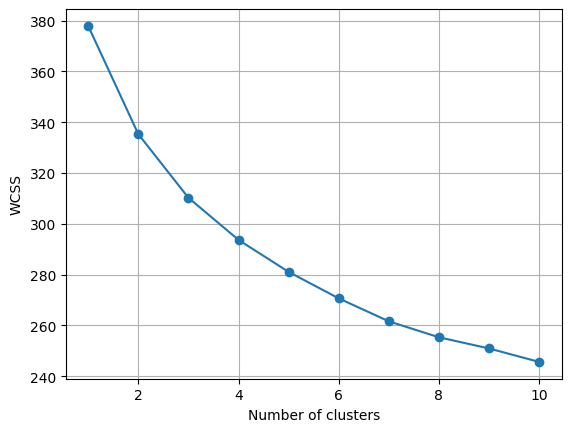

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_cluster_final)
    wcss.append(kmeans.inertia_)
#to identify the elbow point, we will use a visualization
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.savefig('elbow_plot.png')


In [ ]:
#k=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_cluster_final)

df_business['cluster_kmeans'] = clusters

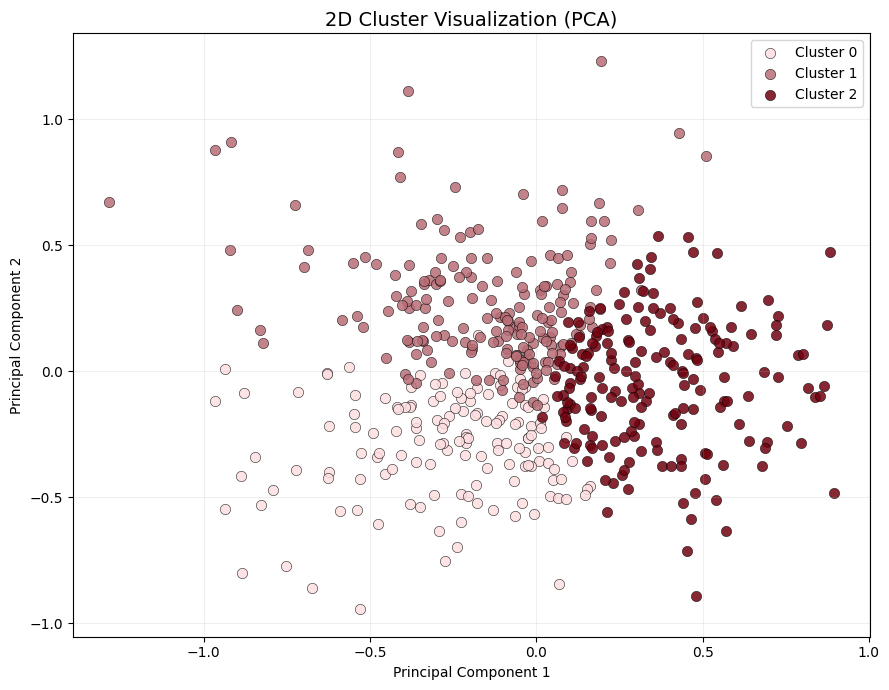

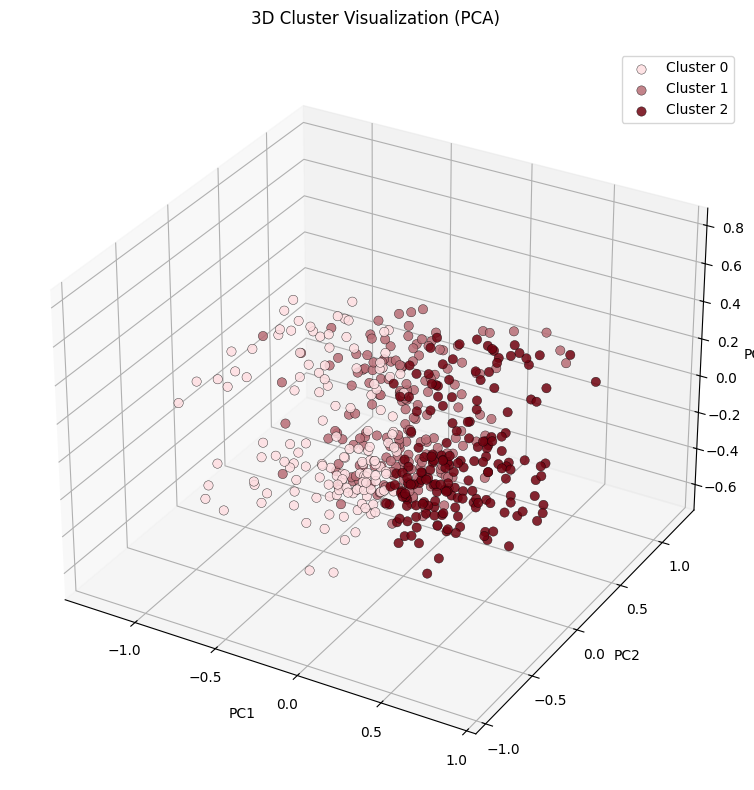

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap

# dfclusterfinal -> scaled feature matrix
# clusters       -> KMeans cluster labels from your notebook

# custom 3-color palette based on your scheme
cluster_palette = ['#fedee1', '#b86d76', '#70020f']

# PCA projections
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(df_cluster_final)

pca_3d = PCA(n_components=3, random_state=42)
X_3d = pca_3d.fit_transform(df_cluster_final)

plot_df_2d = pd.DataFrame(X_2d, columns=['PC1', 'PC2'], index=df_cluster_final.index)
plot_df_2d['cluster'] = clusters

plot_df_3d = pd.DataFrame(X_3d, columns=['PC1', 'PC2', 'PC3'], index=df_cluster_final.index)
plot_df_3d['cluster'] = clusters

# ---------- 2D CLUSTER PLOT ----------
plt.figure(figsize=(9, 7))

for i, color in enumerate(cluster_palette):
    subset = plot_df_2d[plot_df_2d['cluster'] == i]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        s=55,
        color=color,
        edgecolor='black',
        linewidth=0.4,
        alpha=0.85,
        label=f'Cluster {i}'
    )

plt.title('2D Cluster Visualization (PCA)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ---------- 3D CLUSTER PLOT ----------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, color in enumerate(cluster_palette):
    subset = plot_df_3d[plot_df_3d['cluster'] == i]
    ax.scatter(
        subset['PC1'],
        subset['PC2'],
        subset['PC3'],
        s=45,
        color=color,
        edgecolor='black',
        linewidth=0.3,
        alpha=0.85,
        label=f'Cluster {i}'
    )

ax.set_title('3D Cluster Visualization (PCA)', pad=18)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()
plt.tight_layout()
plt.show()


### Clustering  2 (hierarchical)

We cut the dendrogram at k = 3 to enable direct comparison with the K-means partition. Choosing the same k is standard practice when the goal is to compare clustering methods rather than to find the 'best' k for each method independently.



# Evaluation

## Global

### Clustering 1 (k-means)

Rand Index. Given a set of data points, for every pair of points, we ask:



> a = Are pairs in the same cluster in both assignments?

> b = Are pairs in different clusters in both assignments?

> c = pairs in the same cluster in one but different in the other?

> d = pairs in different clusters in one but same in the other?







$$RI = \frac{a + b}{a + b + c + d} = \frac{\text{agreements}}{\text{total pairs}}$$


The RI ranges from 0 to 1, but its problem is that a random clustering can still yield a high RI by chance, especially with many clusters.

The Adjusted Rand Index (ARI)
ARI corrects for chance using the expected value of the Rand Index under a random clustering model.

In [ ]:
# Calculation of RAND INDEX (RI)
from itertools import combinations

def calculate_rand_index(labels_true, labels_pred):
    n = len(labels_true)
    tp_plus_fp = n * (n - 1) / 2

    # a: same cluster, same class
    # b: different cluster, different class
    # c: same cluster, different class
    # d: different cluster, same class

    a = 0
    b = 0
    c = 0
    d = 0

    # We iterate through all unique pairs of indices
    for i, j in combinations(range(n), 2):
        same_class = (labels_true[i] == labels_true[j])
        same_cluster = (labels_pred[i] == labels_pred[j])

        if same_class and same_cluster:
            a += 1
        elif not same_class and not same_cluster:
            b += 1
        elif not same_class and same_cluster:
            c += 1
        elif same_class and not same_cluster:
            d += 1

    ri = (a + b) / (a + b + c + d)
    return ri, a, b, c, d

In [ ]:
# Calculate RI for K-means clusters
# labels_true = y_cluster.values, labels_pred = clusters
ri_value, a, b, c, d = calculate_rand_index(y_cluster.values, clusters)

print(f"k={optimal_k}")
#Adjusted rand index
ari_kmeans = adjusted_rand_score(y_cluster, clusters)
print(f"Adjusted Rand Index (K-means): {ari_kmeans:.4f}")
# low value means that our clusters do not match the acual values (only 5.4%)
# this is not due to our model being disfunctional, but because compatability is complex
print(f"Silhouette Score (K-means): {silhouette_score(df_cluster_final, clusters):.4f}")
print(f"Cluster sizes      : {pd.Series(clusters).value_counts().sort_index().to_dict()}")
print(f"Rand Index (RI): {ri_value:.4f}")
print(f"Agreements (a+b): {a+b}")
print(f"Total pairs: {a+b+c+d}")

k=3
Adjusted Rand Index (K-means): 0.0711
Silhouette Score (K-means): 0.0911
Cluster sizes      : {0: 147, 1: 191, 2: 183}
Rand Index (RI): 0.4856
Agreements (a+b): 65783
Total pairs: 135460


### Clustering 2 (hierarchical)

In [ ]:
K_FINAL = 3

# Dendrogram on a sample (full data is too large to plot)
rng = np.random.default_rng(42)
sample_idx = np.random.choice(len(df_cluster_final), size=min(100, len(df_cluster_final)), replace=False)
Z = linkage(df_cluster_final.iloc[sample_idx], method='ward')



# Fit Agglomerative with same k for comparability
agg_final = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
labels_agg = agg_final.fit_predict(df_cluster_final)

print(f"\nHierarchical Agglomerative (k={K_FINAL}, ward)")
print(f"Silhouette score   : {silhouette_score(df_cluster_final, labels_agg):.4f}")
print(f"Adjusted Rand index: {adjusted_rand_score(y_cluster, labels_agg):.4f}")
print(f"Cluster sizes      : {pd.Series(labels_agg).value_counts().sort_index().to_dict()}")


Hierarchical Agglomerative (k=3, ward)
Silhouette score   : 0.0395
Adjusted Rand index: 0.0347
Cluster sizes      : {0: 189, 1: 170, 2: 162}


In [ ]:
# Calculate RI for hierarchical clusters
# labels_true = y_cluster.values, labels_pred = labels_agg
ri_value, a, b, c, d = calculate_rand_index(y_cluster.values, labels_agg)

print(f"Rand Index (RI): {ri_value:.4f}")
print(f"Agreements (a+b): {a+b}")
print(f"Total pairs: {a+b+c+d}")

Rand Index (RI): 0.4646
Agreements (a+b): 62936
Total pairs: 135460


In [ ]:
# Compute the Adjusted Rand Index for hierarchical clustering
ari_hierarchical = adjusted_rand_score(y_cluster, labels_agg)
print(f"Adjusted Rand Index (Hierarchical): {ari_hierarchical}")

Adjusted Rand Index (Hierarchical): 0.03469351675194154


## Local

In [ ]:
iid_155_rows = df_business[df_business['iid'] == 155]
iid_155_scaled = df_cluster_final.loc[df_cluster_final.index.isin(iid_155_rows.index)]

if len(iid_155_scaled) > 0:
    km_cluster_iid155 = kmeans.predict(iid_155_scaled)
    agg_cluster_iid155 = labels_agg[df_cluster_final.index.get_indexer(iid_155_scaled.index)]
    print(f"\nInstance (155th row) K-Means cluster(s)     : {km_cluster_iid155}")
    print(f"Instance (155th row) Hierarchical cluster(s): {agg_cluster_iid155}")
    # Match values for that instance
    print(f"Match values for 155 row: {y_cluster.loc[iid_155_scaled.index].values}")
else:
    print("The 155 row has no rows surviving the dropna on cluster_features, pick another instance or impute first")


Instance (155th row) K-Means cluster(s)     : [1]
Instance (155th row) Hierarchical cluster(s): [0]
Match values for 155 row: [0]


*	Use the model to classify the chosen instance into a cluster

# Explanation

## Global explanation

### Clustering 1 - k-means

In [ ]:
#Identifying centroids
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df_cluster_final.columns)
centroids['count'] = pd.Series(clusters).value_counts().sort_index().values
display(centroids)

,attractive_o,sinsere_o,intelligence_o,funny_o,ambitous_o,shared_interests_o,attractive_partner,sincere_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,pref_o_ambitious,pref_o_shared_interests,interests_correlate,age,age_o,count
0,6.773184,7.526702,7.715530,6.875274,7.425266,5.931358,4.092626,6.259264,6.385859,4.364205,5.210408,3.612843,17.335850,18.846735,19.967755,16.479184,12.829660,14.404830,0.200272,27.877551,27.016921,147
1,5.469279,6.177227,6.574735,5.507595,6.292798,4.713658,6.251058,7.255698,7.383916,6.695515,6.525767,5.719528,19.386335,18.610942,20.886283,17.121571,10.908691,13.342129,0.218168,27.732984,25.848035,191
2,7.506328,8.111886,8.344662,7.979702,7.980668,7.113683,6.905705,7.487255,7.777166,7.354138,7.184403,6.425365,18.546494,18.027583,20.496781,17.938864,13.519966,11.444790,0.197308,27.289617,26.729301,183


## Clusters
**Cluster 0** (n = 147, match rate 1.4%): Asymmetric: participants were rated relatively well by their partners but rated the partners themselves very low (attractiveness 4.09, fun 4.36, shared interests 3.61). These are "they liked me, I didn't like them" dates.

**Cluster 1** (n = 191, match rate 12.6%): Asymmetric the other way: participants received lower ratings from their partners (attractiveness 5.47, fun 5.51) but gave relatively high ratings back (sincerity 7.26, intelligence 7.38). These are "I liked them, they didn't like me" dates.

**Cluster 2** (n = 183, match rate 46.4%): Mutual chemistry: high ratings in both directions across all dimensions (self-received 7.51 attractiveness, 8.34 intelligence, 7.98 fun; ratings given 6.91 attractiveness, 7.78 intelligence, 7.35 fun). These are the successful dates.




### Clustering 2 - hierarchical

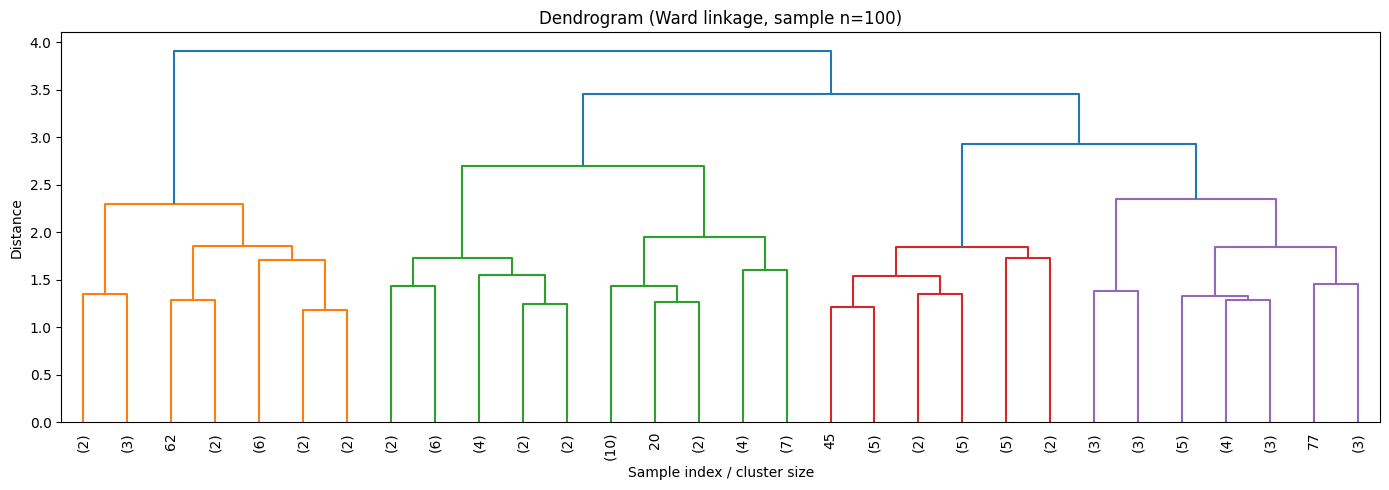

In [ ]:
plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Dendrogram (Ward linkage, sample n=100)')
plt.xlabel('Sample index / cluster size')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

The dendrogram based on Ward linkage suggests that the Business subset can be divided into approximately three broader groups, which is consistent with the selected setting k = 3 for the final hierarchical clustering model. The larger vertical jumps in the upper part of the dendrogram indicate that the final merged groups are more dissimilar, which supports the interpretation that the data contain a coarse multi-group structure. Because the dendrogram was created only from a random sample of 100 observations, it should be treated as an exploratory visualization rather than as a strict criterion for determining the optimal number of clusters.

The final agglomerative clustering with Ward linkage and k = 3 produced three relatively balanced clusters with sizes 189, 170, and 162. However, the quantitative evaluation suggests that the separation between these clusters is weak. The silhouette score of 0.0395 is very low, indicating that many observations lie close to cluster boundaries, and the Adjusted Rand Index of 0.0347 shows only a weak relationship between the clustering result and the observed target variable match. Overall, the hierarchical model provides an exploratory segmentation of Business participants, but the resulting cluster structure should be interpreted cautiously.

# Local explanation of the selected instance

In [ ]:
# Local explanation - selected instance
selected_instance_row = df_business[df_business['iid'] == 155]
selected_instance_scaled = df_cluster_final.loc[df_cluster_final.index.isin(selected_instance_row.index)]

if len(selected_instance_scaled) > 0:
    km_cluster_selected = kmeans.predict(selected_instance_scaled)
    agg_cluster_selected = labels_agg[df_cluster_final.index.get_indexer(selected_instance_scaled.index)]
    selected_match = y_cluster.loc[selected_instance_scaled.index].values[0]
    print(f"K-Means cluster: {km_cluster_selected[0]}")
    print(f"Hierarchical cluster: {agg_cluster_selected[0]}")
    print(f"Observed match value: {selected_match}")
else:
    print("The selected observation is not available after preprocessing.")

K-Means cluster: 1
Hierarchical cluster: 0
Observed match value: 0


In [ ]:
cluster_match_kmeans = df_business[['match', 'cluster_kmeans']].copy()
cluster_match_kmeans['match'] = cluster_match_kmeans['match'].astype(int)

cluster_match_summary_kmeans = cluster_match_kmeans.groupby('cluster_kmeans')['match'].mean()
print("\nAverage match rate by K-Means cluster:")
print(cluster_match_summary_kmeans.round(3))


Average match rate by K-Means cluster:
cluster_kmeans
0    0.014
1    0.126
2    0.464
Name: match, dtype: float64


In [ ]:
assigned_km_cluster = km_cluster_selected[0]
cluster_avg_match = cluster_match_summary_kmeans.loc[assigned_km_cluster]

print(f"\nAverage match rate in assigned K-Means cluster: {cluster_avg_match:.3f}")
print(f"Cluster mode approximation (match > 0.5 -> 1, else 0): {int(cluster_avg_match > 0.5)}")
print(f"Does it agree with selected instance? {int(selected_match) == int(cluster_avg_match > 0.5)}")


Average match rate in assigned K-Means cluster: 0.126
Cluster mode approximation (match > 0.5 -> 1, else 0): 0
Does it agree with selected instance? True


| Model | Assigned cluster |
|---|:---:|
| **K-means** | Cluster 1 |
| **Hierarchical (Ward)** | Cluster 0 |

For the local explanation we selected the instance of interest corresponding to participant iid = 155 in the Business subset. The true class of this observation is match = 0, meaning the date did not result in a mutual match. We now examine how each clustering model assigns this instance and whether those assignments are consistent with the observed outcome.

**Interpretation of the K-means assignment**

K-means placed iid = 155 in Cluster 1, which we previously identified as the "I liked them, they didn't like me" profile: participants who gave relatively positive ratings to their partners but received lower ratings in return. This cluster has an average match rate of 12.6%, which is much lower than the mutual-chemistry cluster (46.4%) but higher than the most critical cluster (1.4%).


Since the observed outcome for iid = 155 is match = 0, and Cluster 1 is dominated by unsuccessful interactions (mode = no match), the K-means assignment is consistent with the true label. Classifying iid = 155 into this cluster would correctly predict no match in this instance, even though the cluster is not perfectly homogeneous on the outcome.

**Interpretation of the hierarchical assignment**

The hierarchical model assigned iid = 155 to its Cluster 0. Because ARI between the two methods is only moderate, we cannot assume this corresponds to any specific K-means cluster. What we can say is that the instance was placed into a different region of the feature space by the two algorithms, which suggests that iid = 155 sits near a boundary between two clusters rather than deep in the core of any single one.

The two methods assigning iid = 155 to different clusters is itself informative: the instance sits near a cluster boundary rather than in the core of any single profile. Both assigned clusters are dominated by match = 0, so the qualitative prediction (no match) is robust across methods. However, any detailed interpretation of the interaction profile, for example, "this is clearly a one-sided date", should be treated with caution, since the two models place the instance in different profile types.

More broadly, this is a reminder that clustering does not produce a definitive label for a single point. Instances near cluster boundaries are best understood as blends of multiple profiles rather than as pure members of any one group.



# Conclusion

**1. Which clustering provided the most useful result?**

The K-means clustering provided the more useful result. While both methods were applied to the same Business subset with k = 3 and both produced three interpretable groups, K-means outperformed hierarchical clustering on every quantitative criterion

The K-means partition aligns roughly twice as closely with the true match label (ARI 0.071 vs 0.035), even though both values are low in absolute terms. More importantly, the K-means clusters differ dramatically in their average match rates, Cluster 0 has only 1.4% matches, Cluster 1 has 12.6%, and Cluster 2 has 46.4%,which is a meaningful signal for a dating platform: participants in the "Cluster 2" profile are more than 30 times more likely to produce a match than those in "Cluster 0". This is exactly the kind of actionable segmentation that makes clustering useful from a business perspective.

Hierarchical clustering acted as a useful validation step rather than as the primary result. The fact that it independently recovered roughly the same three-pattern structure (mutual chemistry + two asymmetric groups) suggests this structure is a genuine feature of the data rather than an artefact of any single algorithm. However, its weaker ARI and very low silhouette score (0.040) confirm that K-means produces a sharper partition.

A caveat worth noting: both ARI values are low in absolute terms, and the silhouette score is close to zero. This is not a failure of the methods, it reflects the fact that romantic compatibility is genuinely high-dimensional and partly random, so rating profiles alone cannot fully separate matches from non-matches. The clusters capture interaction patterns, not match outcomes directly, and we should interpret them as exploratory segmentation rather than as a predictive model.

**2. What setting provided the best result?**
The best-performing configuration was:

Subset: Business participants only (field == "Business"), n = 521 observations
Features: 21 numeric variables covering mutual date-time ratings (*_o, *_partner), partner's pre-event preferences (pref_o_*), interests_correlate, and age/age_o

Algorithm: K-means with n_clusters = 3, init='k-means++', n_init = 10,

Choice of k = 3: justified by the elbow curve on the within-cluster sum of squares (WCSS), which showed the clearest bend at three clusters.

# Dataset export

In [ ]:
# Splitting the business dataset into train and test sets
train_df, test_df = train_test_split(df_business, test_size=0.2, random_state=42)

# Exporting to CSV
train_df.to_csv('train_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)

print("Train data exported to: train_data.csv")
print("Test data exported to: test_data.csv")

Train data exported to: train_data.csv
Test data exported to: test_data.csv


In [ ]:
# === Imputation strategy comparison: how much does it actually move silhouette? ===
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (required)
from sklearn.impute import IterativeImputer

K = 3
SEED = 42

# Same subset and features you used for clustering
df_b = df[df['field'] == 'Business'][cluster_features].copy()
print(f"Rows: {len(df_b)}  |  Features: {len(cluster_features)}")
print(f"Rows with at least one NaN: {df_b.isna().any(axis=1).sum()}")

def cluster_and_score(X, label):
    scaled = MinMaxScaler().fit_transform(X)
    km = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=SEED)
    labels = km.fit_predict(scaled)
    sil = silhouette_score(scaled, labels)
    print(f"{label:<28s}  n={len(X):>4d}  silhouette = {sil:.4f}")
    return sil

results = {}

# --- A) Drop rows with any missing value (no imputation at all) ---
results['dropna'] = cluster_and_score(df_b.dropna(), "A) dropna (no imputation)")

# --- B) Mean imputation (your current approach) ---
mean_imp = SimpleImputer(strategy='mean').fit_transform(df_b)
results['mean'] = cluster_and_score(
    pd.DataFrame(mean_imp, columns=cluster_features), "B) mean imputation")

# --- C) Median imputation ---
median_imp = SimpleImputer(strategy='median').fit_transform(df_b)
results['median'] = cluster_and_score(
    pd.DataFrame(median_imp, columns=cluster_features), "C) median imputation")

# --- D) MICE (IterativeImputer) ---
# Clip to each column's observed range so 1-10 ratings can't escape their bounds.
mins = df_b.min().values
maxs = df_b.max().values
mice = IterativeImputer(
    max_iter=20,
    random_state=SEED,
    sample_posterior=False,
    min_value=mins,
    max_value=maxs,
)
mice_imp = mice.fit_transform(df_b)
results['mice'] = cluster_and_score(
    pd.DataFrame(mice_imp, columns=cluster_features), "D) MICE (IterativeImputer)")

# --- Summary ---
print("\n--- Summary ---")
spread = max(results.values()) - min(results.values())
for k, v in sorted(results.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<10s} : {v:.4f}")
print(f"\nSpread between best and worst: {spread:.4f}")
print("If this spread is < ~0.02, imputation is NOT the silhouette bottleneck.")

Rows: 521  |  Features: 21
Rows with at least one NaN: 169
A) dropna (no imputation)     n= 352  silhouette = 0.0963
B) mean imputation            n= 521  silhouette = 0.0911
C) median imputation          n= 521  silhouette = 0.0931
D) MICE (IterativeImputer)    n= 521  silhouette = 0.0992

--- Summary ---
  mice       : 0.0992
  dropna     : 0.0963
  median     : 0.0931
  mean       : 0.0911

Spread between best and worst: 0.0081
If this spread is < ~0.02, imputation is NOT the silhouette bottleneck.


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
